**Анализ платежей и продуктов: **
1. Изучите распределение типов оплаты и их влияние на успешность сделок.
2. Проанализируйте популярность и успешность различных продуктов и типов
обучения.

Распределение типов оплаты (всех сделок где есть данные)

In [3]:
import pandas as pd
import plotly.express as px

deals_df = pd.read_excel("Deals_f_clean.xlsx", dtype={"Id": str,"Contact Name": str})

# Берём только нужный столбец
df_payment = deals_df[["Payment Type"]].copy()

# Заменяем пропуски для удобства анализа
#df_payment["Payment Type"] = df_payment["Payment Type"].fillna("Не указано")

# Считаем количество сделок по каждому типу оплаты
payment_dist = df_payment["Payment Type"].value_counts().reset_index()
payment_dist.columns = ["Payment Type", "Count"]

# --- График ---
fig = px.bar(
    payment_dist,
    x="Payment Type",
    y="Count",
    text="Count",
    color="Payment Type",
    title="📦 Распределение типов оплаты",
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False, yaxis_title="Количество сделок", xaxis_title="Тип оплаты")

fig.show()

In [4]:
fig.write_json("payment_types2.json")

Такой же график в цвете для презентации:

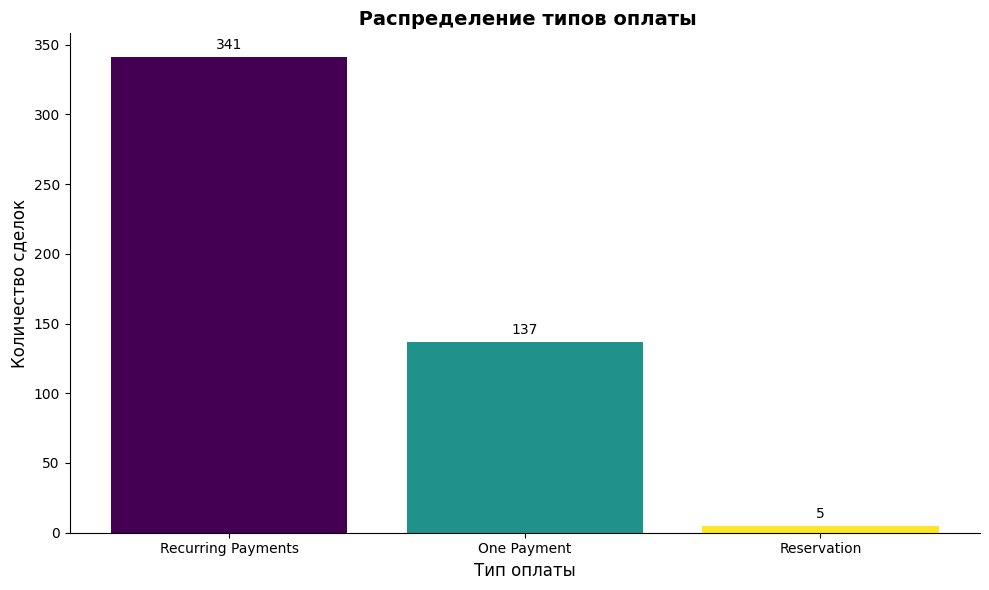

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# payment_dist — DataFrame с колонками "Payment Type" и "Count"
x = payment_dist["Payment Type"]
y = payment_dist["Count"]

# Цвета из colormap Viridis
colors = cm.viridis(np.linspace(0, 1, len(x)))

# --- График ---
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, y, color=colors)

# Подписи над столбцами
for bar, value in zip(bars, y):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(y) * 0.01,
        f"{value}",
        ha='center', va='bottom', fontsize=10
    )

# Настройки осей и заголовка
ax.set_title(" Распределение типов оплаты", fontsize=14, weight='bold')
ax.set_xlabel("Тип оплаты", fontsize=12)
ax.set_ylabel("Количество сделок", fontsize=12)

# Убираем рамку сверху и справа для чистоты
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


Теперь посмотрим на успешность в денежном эквиваленте. Тут считаем только успешные сделки.

In [9]:
import pandas as pd

# --- Фильтруем только успешные сделки ---
success_df = deals_df[deals_df["Stage"] == "Payment Done"].copy()

# --- Группировка по Payment Type ---
payment_stats = (
    success_df
    .groupby("Payment Type", as_index=False)
    .agg(
        deals_count=("Offer Total Amount", "count"),
        revenue=("Offer Total Amount", "sum")
    )
)

# --- Добавляем доли ---
payment_stats["share_of_deals"] = payment_stats["deals_count"] / payment_stats["deals_count"].sum()
payment_stats["share_of_revenue"] = payment_stats["revenue"] / payment_stats["revenue"].sum()

# --- Приводим к удобному виду ---
payment_stats = (
    payment_stats
    .assign(
        share_of_deals=lambda x: (x["share_of_deals"] * 100).round(2),
        share_of_revenue=lambda x: (x["share_of_revenue"] * 100).round(2),
        revenue=lambda x: x["revenue"].round(2)
    )
    .sort_values("revenue", ascending=False)
)

# --- Настройки отображения ---
pd.set_option("display.max_columns", None)     # показывать все столбцы
pd.set_option("display.expand_frame_repr", False)  # не переносить строки
pd.set_option("display.max_rows", 20)          # максимум строк в выводе (можно изменить)

print(payment_stats)


         Payment Type  deals_count    revenue  share_of_deals  share_of_revenue
1  Recurring Payments          247  1102000.0           70.17             74.94
0         One Payment          104   366001.0           29.55             24.89
2         Reservation            1     2500.0            0.28              0.17


А тут - все сделки.

In [12]:
# Количество сделок по типу оплаты (без NaN)
deals_count = deals_df["Payment Type"].value_counts().reset_index()
deals_count.columns = ["Payment Type", "deals_count"]

# Доход по успешным сделкам
revenue = deals_df[deals_df["Stage"] == "Payment Done"].groupby("Payment Type")["Offer Total Amount"].sum().reset_index()
revenue = revenue.rename(columns={"Offer Total Amount": "revenue"})

# Объединяем
payment_stats = pd.merge(deals_count, revenue, on="Payment Type", how="left").fillna(0)

# Доля сделок и дохода
total_deals = payment_stats["deals_count"].sum()
total_revenue = payment_stats["revenue"].sum()
payment_stats["deals_share (%)"] = (payment_stats["deals_count"] / total_deals * 100).round(2)
payment_stats["revenue_share (%)"] = (payment_stats["revenue"] / total_revenue * 100).round(2)

print(payment_stats.to_string(index=False))


      Payment Type  deals_count   revenue  deals_share (%)  revenue_share (%)
Recurring Payments          341 1102000.0            70.60              74.94
       One Payment          137  366001.0            28.36              24.89
       Reservation            5    2500.0             1.04               0.17


Теперь попробуем проанализировать связь метода оплаты и успешности сделки. Успешные считаем - Payment Done, неуспешные - Lost. Остальные промежутоные стадии будем считать нейтральными.



In [ ]:
from scipy.stats import chi2_contingency



# ---  Берем нужные поля ---
df = deals_df[["Stage", "Payment Type"]].copy()

# ---  Очистка данных ---
df = df.dropna(subset=["Payment Type"])   # оставляем только сделки с указанным типом оплаты
df["Stage"] = df["Stage"].fillna("Unknown")

# ---  Создаем бинарную метку успешности ---
df["is_success"] = df["Stage"].map(
    {"Payment Done": 1, "Lost": 0}
)
# Остальные стадии → None (нейтральные)
df["is_success"] = df["is_success"].astype("float")

# ---  Анализ успешности по типам оплаты ---
success_by_payment = (
    df.groupby("Payment Type")["is_success"]
    .mean()
    .reset_index()
    .rename(columns={"is_success": "Success_Rate"})
)

fig2 = px.bar(
    success_by_payment,
    x="Payment Type",
    y="Success_Rate",
    text=success_by_payment["Success_Rate"].apply(lambda x: f"{x:.1%}"),
    title="💰 Успешность сделок по типу оплаты",
    color="Payment Type",
)
fig2.update_traces(textposition="outside")
fig2.update_layout(yaxis_tickformat=".0%", showlegend=False)
fig2.show()

In [ ]:
fig2.write_json("payment_types2.json")

In [ ]:
# ---  Проверка статистической зависимости (хи-квадрат) ---
# Создаем таблицу сопряженности
contingency = pd.crosstab(df["Payment Type"], df["Stage"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("📈 РЕЗУЛЬТАТ ХИ-КВАДРАТ ТЕСТА:")
print(f"χ² = {chi2:.3f}, p-value = {p:.5f}")

if p < 0.05:
    print("✅ Есть статистически значимая связь между типом оплаты и успешностью сделки.")
else:
    print("❌ Связь между типом оплаты и успешностью сделки не обнаружена.")

📈 РЕЗУЛЬТАТ ХИ-КВАДРАТ ТЕСТА:
χ² = 23.033, p-value = 0.01062
✅ Есть статистически значимая связь между типом оплаты и успешностью сделки.


!!! Однако этот анализ не отображает реальность, так как поле Payment Type заполнено преимещественно только тогда, когда сделка успешная.

При этом, можно сделать вывод, что отказываются от сделки уже на финальном этапе больше при рассрочке, чем при единоразовом платеже.

In [ ]:
# Заменяем Stage на удобные категории
deals_df["Stage"] = deals_df["Stage"].fillna("Не указано")
deals_df["Payment Type"] = deals_df["Payment Type"].fillna("Не указано")

# Создаём индикатор заполненности
deals_df["Payment_Filled"] = deals_df["Payment Type"] != "Не указано"

# Считаем долю заполненных для каждой стадии
filled_stats = (
    deals_df.groupby("Stage")["Payment_Filled"]
    .mean()
    .reset_index()
    .sort_values("Payment_Filled", ascending=False)
)

filled_stats["Payment_Filled"] = filled_stats["Payment_Filled"] * 100  # в проценты
print(filled_stats)


                        Stage  Payment_Filled
7                Payment Done       42.406542
8                Qualificated        3.906250
12        Waiting For Payment        0.925926
2                        Lost        0.714439
0                Call Delayed        0.490415
10      Registered on Webinar        0.048309
4         Need a consultation        0.000000
1              Free Education        0.000000
3                Need To Call        0.000000
5        Need to Call - Sales        0.000000
6                    New Lead        0.000000
9   Registered on Offline Day        0.000000
11                  Test Sent        0.000000


In [ ]:
fig3 = px.bar(
    filled_stats,
    x="Stage",
    y="Payment_Filled",
    text=filled_stats["Payment_Filled"].round(1).astype(str) + "%",
    title="📉 Заполненность поля Payment Type по стадиям сделки",
    color="Stage"
)
fig3.update_traces(textposition="outside")
fig3.update_layout(
    yaxis_title="Доля заполненных, %",
    xaxis_title="Стадия сделки",
    showlegend=False
)
fig3.show()


In [ ]:
fig3.write_json("payment_types3.json")

⚠️ Поле Payment Type в данных заполняется преимущественно для успешных сделок (Stage = "Payment Done").
Для остальных стадий доля заполненных значений крайне мала.
Поэтому анализ распределения типов оплаты отражает не реальную структуру оплаты клиентов, а особенности ведения данных.

2. Проанализируйте популярность и успешность различных продуктов и типов
обучения.

Заполненность и популярность Product

In [ ]:
# --- 1. Проверим заполненность поля Product ---
product_fill_rate = deals_df["Product"].notna().mean() * 100
print(f"Заполненность поля Product: {product_fill_rate:.1f}%")

# --- 2. Посмотрим топ популярных продуктов ---
product_popularity = (
    deals_df["Product"]
    .value_counts(dropna=True)
    .reset_index()
    .rename(columns={"index": "Product", "Product": "Count"})
)
print("\nПопулярность продуктов:")
print(product_popularity)


Заполненность поля Product: 17.8%

Популярность продуктов:
                 Count  count
0    Digital Marketing   1953
1         UX/UI Design   1013
2        Web Developer    567
3  Find yourself in IT      3
4       Data Analytics      1


Заполненность и популярность Education Type

In [ ]:
# --- 1. Проверим заполненность поля Education Type ---
edu_fill_rate = deals_df["Education Type"].notna().mean() * 100
print(f"\nЗаполненность поля Education Type: {edu_fill_rate:.1f}%")

# --- 2. Посмотрим топ популярных типов обучения ---
edu_popularity = (
    deals_df["Education Type"]
    .value_counts(dropna=True)
    .reset_index()
    .rename(columns={"index": "Education Type", "Education Type": "Count"})
)
print("\nПопулярность типов обучения:")
print(edu_popularity)



Заполненность поля Education Type: 16.4%

Популярность типов обучения:
     Count  count
0  Morning   2858
1  Evening    398


Успешность по Education Type (визуально)

In [ ]:
# 0. Подготовка: берем только нужные столбцы, убираем NaN в Education Type и Stage
df2 = deals_df[["Education Type", "Stage"]].copy()
df2["Education Type"] = df2["Education Type"].fillna("Не указано")
df2["Stage"] = df2["Stage"].fillna("Не указано")

# Если нужны только Morning/Evening (и игнорировать остальные):
df2 = df2[df2["Education Type"].isin(["Morning", "Evening"])].copy()

# 1. Считаем количества по (Education Type, Stage)
group = (
    df2.groupby(["Education Type", "Stage"])
    .size()
    .reset_index(name="Count")
)

# 2. Общие суммы по каждому Education Type
totals = group.groupby("Education Type", as_index=False)["Count"].sum().rename(columns={"Count":"Total"})

# 3. Добавляем процент внутри каждого Education Type
group = group.merge(totals, on="Education Type", how="left")
group["Percent"] = 100 * group["Count"] / group["Total"]

# 4. Опционально — подпись текста: показываем процент с 1 знаком, но если сегмент слишком мал (<2%) оставим пустую подпись
LABEL_THRESHOLD = 2.0  # проценты ниже этого порога не печатаются внутри сегмента
group["Label"] = group["Percent"].apply(lambda x: f"{x:.1f}%" if x >= LABEL_THRESHOLD else "")

# 5. Убедимся в порядке категорий (чтобы первый был Morning, потом Evening)
category_order = ["Morning", "Evening"]
group["Education Type"] = pd.Categorical(group["Education Type"], categories=category_order, ordered=True)

# 6. Строим stacked horizontal bar
fig4 = px.bar(
    group,
    y="Education Type",
    x="Count",
    color="Stage",
    orientation="h",
    text="Label",
    category_orders={"Education Type": category_order},
    title="Распределение стадий (Stage) внутри Education Type (Morning / Evening)",
)

# 7. Настройки отображения текста внутри сегментов
fig4.update_traces(textposition="inside", insidetextanchor="middle")
fig4.update_traces(textfont=dict(color="white", size=11))

# 8. Добавим справа от каждого бара общее количество сделок (Total)
# Для удобства найдём максим X, чтобы смещать подпись справа
max_total = group["Total"].max()
# уникальные Education Type в порядке отображения
edu_order = list(group["Education Type"].cat.categories)

for i, edu in enumerate(edu_order):
    total_val = int(totals.loc[totals["Education Type"] == edu, "Total"].iloc[0]) if edu in totals["Education Type"].values else 0
    # координаты: x = total_val + небольшой сдвиг; y = имя категории
    fig.add_annotation(
        x=total_val + max_total * 0.03,  # сдвиг вправо 3% от макс
        y=edu,
        text=f"Всего: {total_val}",
        showarrow=False,
        font=dict(size=12, color="black"),
        xanchor="left",
        yanchor="middle",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=4
    )

# 9. Финальная косметика
fig4.update_layout(
    xaxis_title="Количество сделок",
    yaxis_title="Тип обучения",
    legend_title="Stage",
    barmode="stack",
    template="plotly_white",
    height=400
)

fig4.show()


In [ ]:
fig4.write_json("education_type.json")

теперь  по Product

In [ ]:
# 0. Подготовка: берем только нужные столбцы, убираем NaN в Education Type и Stage
df3 = deals_df[["Product", "Stage"]].copy()
df3["Product"] = df3["Product"].fillna("Не указано")
df3["Stage"] = df3["Stage"].fillna("Не указано")

# Если нужны только Morning/Evening (и игнорировать остальные):
df3 = df3[df3["Product"] != "Не указано"].copy()

# 1. Считаем количества по (Education Type, Stage)
group2 = (
    df3.groupby(["Product", "Stage"])
    .size()
    .reset_index(name="Count")
)

# 2. Общие суммы по каждому Education Type
totals2 = group2.groupby("Product", as_index=False)["Count"].sum().rename(columns={"Count":"Total"})

# 3. Добавляем процент внутри каждого Education Type
group2 = group2.merge(totals2, on="Product", how="left")
group2["Percent"] = 100 * group2["Count"] / group2["Total"]

# 4. Опционально — подпись текста: показываем процент с 1 знаком, но если сегмент слишком мал (<2%) оставим пустую подпись
LABEL_THRESHOLD = 2.0  # проценты ниже этого порога не печатаются внутри сегмента
group2["Label"] = group2["Percent"].apply(lambda x: f"{x:.1f}%" if x >= LABEL_THRESHOLD else "")

# 5. Убедимся в порядке категорий (чтобы первый был Morning, потом Evening)

group2["Product"] = pd.Categorical(group2["Product"],  ordered=True)

# 6. Строим stacked horizontal bar
fig5 = px.bar(
    group2,
    y="Product",
    x="Count",
    color="Stage",
    orientation="h",
    text="Label",
    title="Распределение стадий (Stage) внутри Product",
)

# 7. Настройки отображения текста внутри сегментов
fig5.update_traces(textposition="inside", insidetextanchor="middle")
fig5.update_traces(textfont=dict(color="white", size=11))

# 8. Добавим справа от каждого бара общее количество сделок (Total)
# Для удобства найдём максим X, чтобы смещать подпись справа
max_total2 = group2["Total"].max()
# уникальные Education Type в порядке отображения
prod_order = list(group2["Product"].cat.categories)

for i, prod in enumerate(prod_order):
    total_val = int(totals2.loc[totals2["Product"] == prod, "Total"].iloc[0]) if prod in totals2["Product"].values else 0
    # координаты: x = total_val + небольшой сдвиг; y = имя категории
    fig5.add_annotation(
        x=total_val + max_total2 * 0.03,  # сдвиг вправо 3% от макс
        y=prod,
        text=f"Всего: {total_val}",
        showarrow=False,
        font=dict(size=12, color="black"),
        xanchor="left",
        yanchor="middle",
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=4
    )

# 9. Финальная косметика
fig5.update_layout(
    xaxis_title="Количество сделок",
    yaxis_title="Тип обучения",
    legend_title="Stage",
    barmode="stack",
    template="plotly_white",
    height=400
)

fig5.show()


In [ ]:
fig5.write_json("product.json")

А теперь в денежном эквиваленте

In [ ]:
# Фильтрация успешных сделок
successful_deals2 = deals_df[
    (deals_df["Stage"] == "Payment Done") &
    (deals_df["Offer Total Amount"].notna())
].copy()

# --- Анализ по Product ---
product_revenue = (
    successful_deals2[
        successful_deals2["Product"].notna() &
        (successful_deals2["Product"] != "Не указано")
    ]
    .groupby("Product", as_index=False)["Offer Total Amount"]
    .sum()
)

# Добавляем долю
total_product_revenue = product_revenue["Offer Total Amount"].sum()
product_revenue["Share (%)"] = (
    product_revenue["Offer Total Amount"] / total_product_revenue * 100
).round(2)

product_revenue = product_revenue.sort_values("Offer Total Amount", ascending=False)

print("💰 Доход по продуктам и их доля в общем доходе:")
print(product_revenue)


# --- Анализ по Education Type ---
education_revenue = (
    successful_deals2[
        successful_deals2["Education Type"].notna() &
        (successful_deals2["Education Type"] != "Не указано")
    ]
    .groupby("Education Type", as_index=False)["Offer Total Amount"]
    .sum()
)

# Добавляем долю
total_edu_revenue = education_revenue["Offer Total Amount"].sum()
education_revenue["Share (%)"] = (
    education_revenue["Offer Total Amount"] / total_edu_revenue * 100
).round(2)

education_revenue = education_revenue.sort_values("Offer Total Amount", ascending=False)

print("\n💰 Доход по типам обучения и их доля в общем доходе:")
print(education_revenue)


💰 Доход по продуктам и их доля в общем доходе:
               Product  Offer Total Amount  Share (%)
0    Digital Marketing           3892400.0      61.98
2         UX/UI Design           1816000.0      28.92
3        Web Developer            571500.0       9.10
1  Find yourself in IT                 1.0       0.00

💰 Доход по типам обучения и их доля в общем доходе:
  Education Type  Offer Total Amount  Share (%)
1        Morning           5583900.0      90.06
0        Evening            616000.0       9.94


Теперь добавим популярность, популярность посчитаем по всем продуктами и типам обучения.

In [13]:
# --- Фильтрация успешных сделок для расчёта дохода ---
successful_deals2 = deals_df[
    (deals_df["Stage"] == "Payment Done") &
    (deals_df["Offer Total Amount"].notna())
].copy()

# ===============================
# 1️⃣ Анализ по Product
# ===============================

# Доход по успешным сделкам
product_revenue = (
    successful_deals2[
        successful_deals2["Product"].notna() &
        (successful_deals2["Product"] != "Не указано")
    ]
    .groupby("Product", as_index=False)["Offer Total Amount"]
    .sum()
    .rename(columns={"Offer Total Amount": "Revenue"})
)

# Общее количество сделок (все, не только успешные)
product_count = (
    deals_df[
        deals_df["Product"].notna() &
        (deals_df["Product"] != "Не указано")
    ]
    .groupby("Product", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

# Объединяем количество и доход
product_stats = pd.merge(product_count, product_revenue, on="Product", how="left").fillna(0)

# Доли
product_stats["Count Share (%)"] = (
    product_stats["Count"] / product_stats["Count"].sum() * 100
).round(2)
product_stats["Revenue Share (%)"] = (
    product_stats["Revenue"] / product_stats["Revenue"].sum() * 100
).round(2)

# Сортировка по доходу
product_stats = product_stats.sort_values("Revenue", ascending=False)

print("💰 Доход и популярность по продуктам:")
print(product_stats.to_string(index=False))


# ===============================
# 2️⃣ Анализ по Education Type
# ===============================

# Доход по успешным
education_revenue = (
    successful_deals2[
        successful_deals2["Education Type"].notna() &
        (successful_deals2["Education Type"] != "Не указано")
    ]
    .groupby("Education Type", as_index=False)["Offer Total Amount"]
    .sum()
    .rename(columns={"Offer Total Amount": "Revenue"})
)

# Количество всех сделок
education_count = (
    deals_df[
        deals_df["Education Type"].notna() &
        (deals_df["Education Type"] != "Не указано")
    ]
    .groupby("Education Type", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

# Объединяем
education_stats = pd.merge(education_count, education_revenue, on="Education Type", how="left").fillna(0)

# Доли
education_stats["Count Share (%)"] = (
    education_stats["Count"] / education_stats["Count"].sum() * 100
).round(2)
education_stats["Revenue Share (%)"] = (
    education_stats["Revenue"] / education_stats["Revenue"].sum() * 100
).round(2)

# Сортировка
education_stats = education_stats.sort_values("Revenue", ascending=False)

print("\n💰 Доход и популярность по типам обучения:")
print(education_stats.to_string(index=False))


💰 Доход и популярность по продуктам:
            Product  Count   Revenue  Count Share (%)  Revenue Share (%)
  Digital Marketing   1953 3892400.0            55.22              61.98
       UX/UI Design   1013 1816000.0            28.64              28.92
      Web Developer    567  571500.0            16.03               9.10
Find yourself in IT      3       1.0             0.08               0.00
     Data Analytics      1       0.0             0.03               0.00

💰 Доход и популярность по типам обучения:
Education Type  Count   Revenue  Count Share (%)  Revenue Share (%)
       Morning   2858 5583900.0            87.78              90.06
       Evening    398  616000.0            12.22               9.94


А теперь посмотриа по типу обучения внутри каждого продукта.

In [15]:
# --- Фильтрация успешных сделок для дохода ---
successful_deals2 = deals_df[
    (deals_df["Stage"] == "Payment Done") &
    (deals_df["Offer Total Amount"].notna())
].copy()

# --- Доход по Product + Education Type ---
edu_product_revenue = (
    successful_deals2[
        successful_deals2["Product"].notna() &
        successful_deals2["Education Type"].notna() &
        (successful_deals2["Product"] != "Не указано") &
        (successful_deals2["Education Type"] != "Не указано")
    ]
    .groupby(["Product", "Education Type"], as_index=False)["Offer Total Amount"]
    .sum()
    .rename(columns={"Offer Total Amount": "Revenue"})
)

# --- Количество всех сделок (по всем Stage) ---
edu_product_count = (
    deals_df[
        deals_df["Product"].notna() &
        deals_df["Education Type"].notna() &
        (deals_df["Product"] != "Не указано") &
        (deals_df["Education Type"] != "Не указано")
    ]
    .groupby(["Product", "Education Type"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

# --- Объединяем количество и доход ---
edu_product_stats = pd.merge(
    edu_product_count, edu_product_revenue,
    on=["Product", "Education Type"], how="left"
).fillna(0)

# --- Добавляем доли внутри каждого продукта ---
edu_product_stats["Count Share (%)"] = (
    edu_product_stats.groupby("Product")["Count"]
    .transform(lambda x: (x / x.sum() * 100).round(2))
)

edu_product_stats["Revenue Share (%)"] = (
    edu_product_stats.groupby("Product")["Revenue"]
    .transform(lambda x: (x / x.sum() * 100).round(2))
)

# --- Сортировка для удобства ---
edu_product_stats = edu_product_stats.sort_values(
    ["Product", "Revenue"], ascending=[True, False]
)

# --- Вывод ---
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

print("📊 Доли типов обучения внутри каждого продукта:")
print(edu_product_stats.to_string(index=False))


📊 Доли типов обучения внутри каждого продукта:
          Product Education Type  Count   Revenue  Count Share (%)  Revenue Share (%)
Digital Marketing        Morning   1509 3409400.0            85.98              89.43
Digital Marketing        Evening    246  403000.0            14.02              10.57
     UX/UI Design        Morning    802 1603000.0            84.16              88.27
     UX/UI Design        Evening    151  213000.0            15.84              11.73
    Web Developer        Morning    538  571500.0            99.81             100.00
    Web Developer        Evening      1       0.0             0.19               0.00


Еще хочу посмотреть распределение продуктов по топ-5 городам.

In [17]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Подготовка данных ---
# Убираем пропуски
df_city_product = deals_df[
    deals_df["City"].notna() & deals_df["Product"].notna()
].copy()

# Топ-5 городов по количеству сделок
top_cities = (
    df_city_product["City"]
    .value_counts()
    .head(5)
    .index.tolist()
)

# Фильтруем только эти города
df_top_cities = df_city_product[df_city_product["City"].isin(top_cities)]

# Группируем по городам и продуктам
popularity = (
    df_top_cities
    .groupby(["City", "Product"])
    .size()
    .reset_index(name="Count")
)

# --- 2. Визуализация ---
fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=top_cities,
    shared_yaxes=False,
    horizontal_spacing=0.05
)

for i, city in enumerate(top_cities):
    city_data = popularity[popularity["City"] == city]
    fig.add_trace(
        go.Bar(
            x=city_data["Product"],
            y=city_data["Count"],
            name=city,
            marker_color="#2E91E5",
            text=city_data["Count"],
            textposition="outside"
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title="Популярность продуктов в топ-5 городах",
    height=600,
    width=1800,
    showlegend=False,
    plot_bgcolor="white",
    margin=dict(t=100)
)

fig.update_yaxes(title_text="Количество сделок")
fig.update_xaxes(title_text="Продукт")

fig.show()


In [18]:
fig.write_json("product_city.json")

График для презентации

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2499059490.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

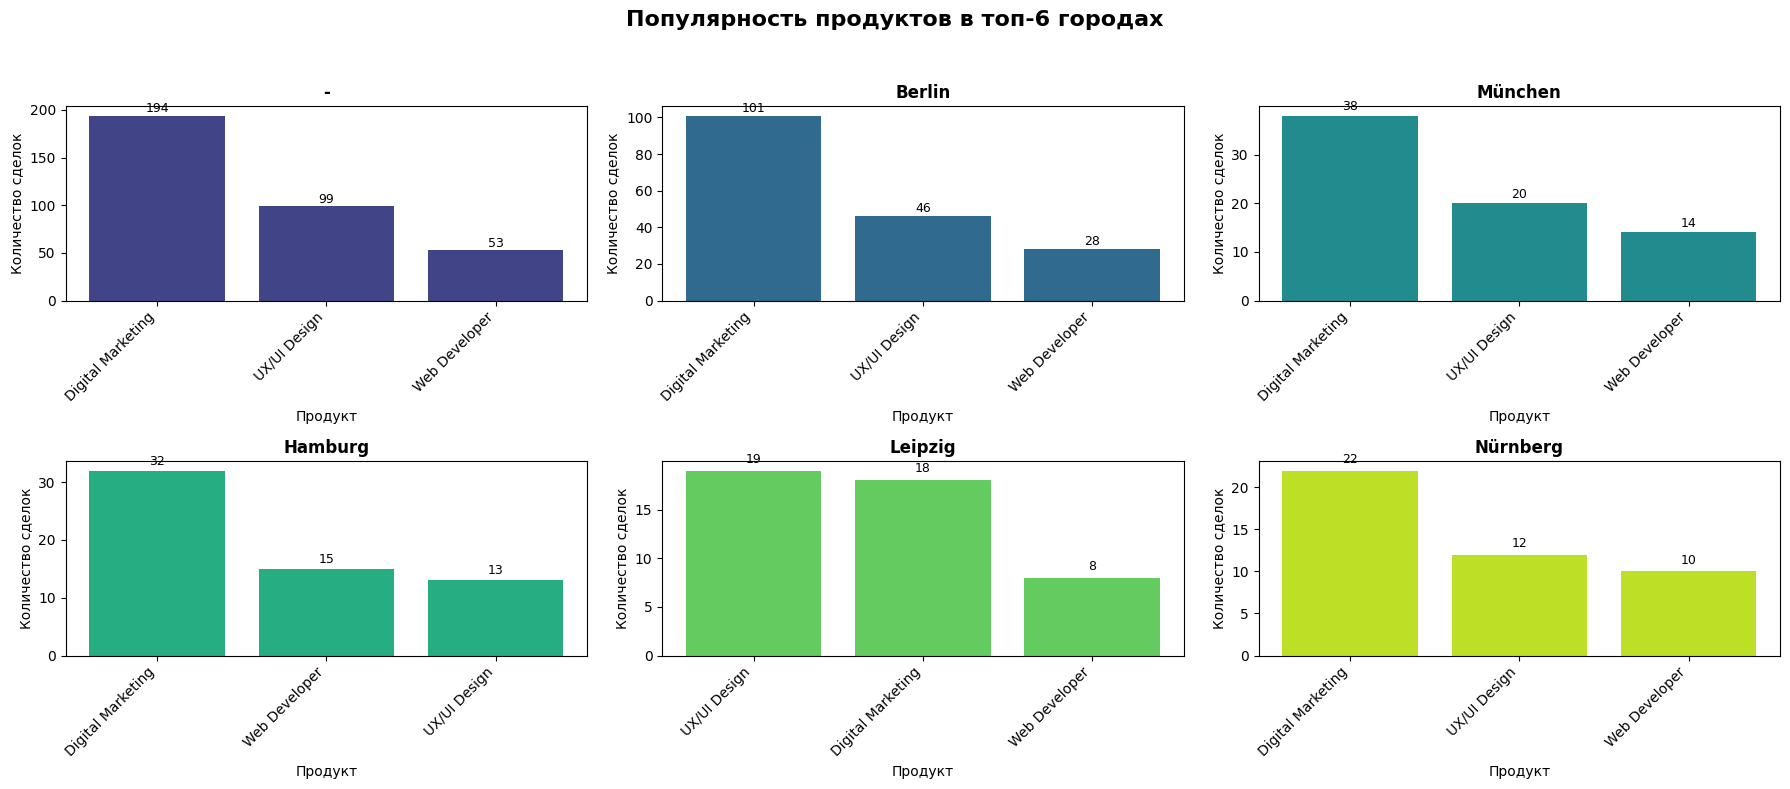

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- 1. Подготовка данных ---
df_city_product = deals_df[
    deals_df["City"].notna() & deals_df["Product"].notna()
].copy()

# Топ-6 городов по количеству сделок
top_cities = (
    df_city_product["City"]
    .value_counts()
    .head(6)
    .index.tolist()
)

# Фильтруем только топ-6
df_top_cities = df_city_product[df_city_product["City"].isin(top_cities)]

# Группируем по городу и продукту
popularity = (
    df_top_cities
    .groupby(["City", "Product"])
    .size()
    .reset_index(name="Count")
)

# --- 2. Визуализация ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Популярность продуктов в топ-6 городах", fontsize=16, fontweight="bold")

# Колormap для городов
colors = cm.viridis(np.linspace(0.2, 0.9, len(top_cities)))

for i, city in enumerate(top_cities):
    row, col = divmod(i, 3)
    ax = axes[row, col]

    city_data = popularity[popularity["City"] == city].sort_values("Count", ascending=False)

    bars = ax.bar(city_data["Product"], city_data["Count"], color=colors[i])
    ax.set_title(city, fontsize=12, fontweight="bold")
    ax.set_xlabel("Продукт")
    ax.set_ylabel("Количество сделок")
    ax.set_xticklabels(city_data["Product"], rotation=45, ha='right')

    # Подписи над барами
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{int(height)}",
                ha='center', va='bottom', fontsize=9)

# Убираем пустые оси, если они есть
if len(top_cities) < 6:
    for j in range(len(top_cities), 6):
        fig.delaxes(axes.flat[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Еще заметила, что иногда клиенты подают заявку на один курс, а потом меняют решение и учатся на другом. Хочу посмотреть сколько таких людей.

In [22]:
sorted(deals_df["Page"].dropna().unique())



['/',
 '/account',
 '/at-end/web-developer',
 '/at-eng',
 '/at-eng/digital-marketing',
 '/at-ru/ux/ui',
 '/at/digital-marketing',
 '/course',
 '/digital-marketing',
 '/direct',
 '/email',
 '/eng',
 '/eng/career',
 '/eng/test',
 '/eng/ux-ui',
 '/event',
 '/offer',
 '/page',
 '/pl-eng',
 '/pl-eng/digital-marketing',
 '/pl-eng/ux-ui',
 '/pl-eng/web-developer',
 '/ppc',
 '/smm',
 '/specialoffer',
 '/test',
 '/ux-ui',
 '/web-developer',
 '/webinar',
 '/welcomepage',
 '/workshop',
 'eng/digital-marketing',
 'eng/web-developer']

In [23]:
page_to_product = {
    '/at-end/web-developer': 'Web Developer',
    '/pl-eng/web-developer': 'Web Developer',
    '/web-developer': 'Web Developer',
    'eng/web-developer': 'Web Developer',

    '/at-eng/digital-marketing': 'Digital Marketing',
    '/at/digital-marketing': 'Digital Marketing',
    '/digital-marketing': 'Digital Marketing',
    '/pl-eng/digital-marketing': 'Digital Marketing',
    'eng/digital-marketing': 'Digital Marketing',

    '/at-ru/ux/ui': 'UX/UI Design',
    '/eng/ux-ui': 'UX/UI Design',
    '/pl-eng/ux-ui': 'UX/UI Design',
    '/ux-ui': 'UX/UI Design',
}


In [24]:
deals_df["Page_Product"] = deals_df["Page"].map(page_to_product)


In [25]:
comparison_df = deals_df[
    deals_df["Page_Product"].notna() & deals_df["Product"].notna()
].copy()


In [26]:
comparison_df["Match"] = np.where(
    comparison_df["Page_Product"] == comparison_df["Product"],
    "Совпадает",
    "Разное"
)

# Сводная таблица
match_summary = comparison_df["Match"].value_counts(normalize=True) * 100
print(match_summary)


Match
Совпадает    72.796353
Разное       27.203647
Name: proportion, dtype: float64


Посмотрим, на какие курсы чаще переключались:

In [27]:
switches = (
    comparison_df[comparison_df["Match"] == "Разное"]
    .groupby(["Page_Product", "Product"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)
print(switches)


        Page_Product            Product  Count
0  Digital Marketing       UX/UI Design    123
2       UX/UI Design  Digital Marketing    106
1  Digital Marketing      Web Developer     48
4      Web Developer  Digital Marketing     29
3       UX/UI Design      Web Developer     27
5      Web Developer       UX/UI Design     25


И посмотрим как часто люди меняют решение.

In [30]:
# Фильтруем только те строки, где человек сменил продукт
switched_df = comparison_df[
    (comparison_df["Match"] == "Разное") &
    comparison_df["Page_Product"].notna() &
    comparison_df["Product"].notna()
].copy()

# Считаем количество людей, которые сменили продукт для каждого исходного курса
switch_count = (
    switched_df.groupby("Page_Product")
    .size()
    .reset_index(name="Switched_Count")
)

# Считаем общее количество людей для каждого исходного курса
total_count = (
    comparison_df[comparison_df["Page_Product"].notna()]
    .groupby("Page_Product")
    .size()
    .reset_index(name="Total_Count")
)

# Объединяем и считаем долю
switch_summary = pd.merge(switch_count, total_count, on="Page_Product")
switch_summary["Switched_Share (%)"] = (
    switch_summary["Switched_Count"] / switch_summary["Total_Count"] * 100
).round(2)

# Сортируем по количеству смен
switch_summary = switch_summary.sort_values("Switched_Count", ascending=False)

print(switch_summary)


        Page_Product  Switched_Count  Total_Count  Switched_Share (%)
0  Digital Marketing             171          883               19.37
1       UX/UI Design             133          312               42.63
2      Web Developer              54          121               44.63
